# Phase 5 — Recording, replay, visualization and manual flight

A simulator you cannot *look at* is a simulator you cannot trust. The roadmap's rule for RL is
blunt: **always watch the trajectories, not only the reward curve** — several bugs and
"reward hacks" in phase 8 were only visible on a 3D replay. This phase provides the tools:

* a **flight recorder** (states, controls, instruments, events) with **bit-exact replay**;
* **plots**: time series and 3D trajectory;
* **Tacview export**: the free 3D flight-analysis tool used by real air forces and flight-sim
  communities;
* a **manual flight** mode with pygame — the ultimate sanity check: if a human cannot fly the
  model, an agent will not either.

Code: `src/jetfighter/viz/` — `recorder.py`, `plots.py`, `tacview.py`, `manual.py`.

In [1]:
%matplotlib inline
import math
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from jetfighter.aircraft import dynamics_6dof as d6
from jetfighter.aircraft.envelope import EnvelopeMonitor
from jetfighter.aircraft.instruments import read_instruments
from jetfighter.aircraft.params import load_aircraft, load_envelope
from jetfighter.viz.recorder import FlightRecorder, FlightRecording, replay
from jetfighter.viz.style import GRID, INK, INK_2, SERIES, apply_style
from jetfighter.viz.tacview import export_recording

apply_style()
plt.rcParams["figure.dpi"] = 110
DEG = math.pi / 180
ROOT = Path.cwd().parent
TMP = Path(tempfile.mkdtemp())

## 1. Flying a scripted demo: a loop, then an aileron roll

The 6-DOF F-16 is flown **open loop** (pre-programmed stick inputs) by a tiny sequencer that
watches the instruments to know when each figure is complete:

* **loop**: full throttle and −4° of elevator until the flight path has turned 355°;
* **roll**: −10° of aileron until the aircraft has rolled ~290° (roll inertia finishes the turn).

Tuning those numbers by hand is fiddly — which is exactly what phases 6–8 are about.

In [2]:
model = d6.F16SixDof(load_aircraft("f16"))
monitor = EnvelopeMonitor(load_envelope("f16", six_dof=True))
x, u0 = model.trim(3000.0, 250.0)
DT, SUBSTEPS = 0.01, 10  # physics at 100 Hz, record/decide at 10 Hz
recorder = FlightRecorder(model, physics_dt=DT, substeps=SUBSTEPS, metadata={"demo": "loop+roll"})


def wrap(a):
    return (a + math.pi) % (2 * math.pi) - math.pi


phase, t_phase, path_angle, roll_angle, prev, course0 = "level", 0.0, 0.0, 0.0, None, None
t, t_end = 0.0, 60.0
while t < t_end:
    ins = read_instruments(model, x)
    course0 = ins.course if course0 is None else course0
    v_along = ins.tas * math.cos(ins.gamma) * math.cos(ins.course - course0)
    path = math.atan2(ins.vertical_speed, v_along)  # flight-path angle in the loop plane
    if prev is not None:
        path_angle += wrap(path - prev[0])
        roll_angle += wrap(ins.roll - prev[1])
    prev = (path, ins.roll)

    new_phase = phase
    if phase == "level" and t >= 2.0:
        new_phase, path_angle = "loop", 0.0
    elif phase == "loop" and path_angle >= 355 * DEG:
        new_phase = "level after loop"
    elif phase == "level after loop" and t - t_phase >= 3.0:
        new_phase, roll_angle = "roll", 0.0
    elif phase == "roll" and abs(roll_angle) >= 287 * DEG:
        new_phase, t_end = "end", t + 6.0
    if new_phase != phase:
        phase, t_phase = new_phase, t
        recorder.event(t, phase)

    u = u0.copy()
    if phase == "loop":
        u[d6.THROTTLE], u[d6.ELEVATOR] = 1.0, u0[d6.ELEVATOR] - 4 * DEG
    elif phase == "roll":
        u[d6.AILERON] = -10 * DEG  # negative aileron = roll right
    recorder.record(t, x, u)
    for _ in range(SUBSTEPS):
        x = model.step(x, u, DT)
    t = round(t + DT * SUBSTEPS, 6)
    if monitor.check(read_instruments(model, x), DT * SUBSTEPS, state=x) is not None:
        recorder.event(t, monitor.message)
        break

flight = recorder.finish()
print(f"{len(flight)} samples, {flight.duration:.1f} s of flight")
for t_event, message in flight.events:
    print(f"  event at {t_event:5.1f} s: {message}")

382 samples, 38.1 s of flight
  event at   2.0 s: loop
  event at  27.6 s: level after loop
  event at  30.6 s: roll
  event at  32.2 s: end


## 2. What a recording contains, and why replay must be exact

A `FlightRecording` stores, at each recorded instant, the raw model state, the control applied
until the next instant, all 28 instruments, plus timestamped events and what is needed to
rebuild the model. It is saved as a plain `.npz` (readable with `numpy.load`, no project code
needed).

In [3]:
path = flight.save(TMP / "demo.npz")
with np.load(path) as data:
    for key in data.files:
        print(f"{key:<18} shape {data[key].shape}")

t                  shape (382,)
states             shape (382, 17)
controls           shape (382, 4)
instrument_names   shape (28,)
instruments        shape (28, 382)
header             shape ()


Because the simulation is **deterministic** (fixed step, no hidden randomness), re-simulating
from the initial state with the recorded controls must reproduce the flight *bit for bit*.
This matters for RL: any episode seen during training can be replayed and inspected exactly.

In [4]:
loaded = FlightRecording.load(path)
states = replay(loaded)
print(
    f"max |replayed − recorded| over all {states.size:,} state values: "
    f"{np.abs(states - loaded.states).max():.1e}"
)

max |replayed − recorded| over all 6,494 state values: 0.0e+00


## 3. Plots

The library has ready-made figures (`plot_time_series`, `plot_trajectory_3d`); here is an
English version of the same views.

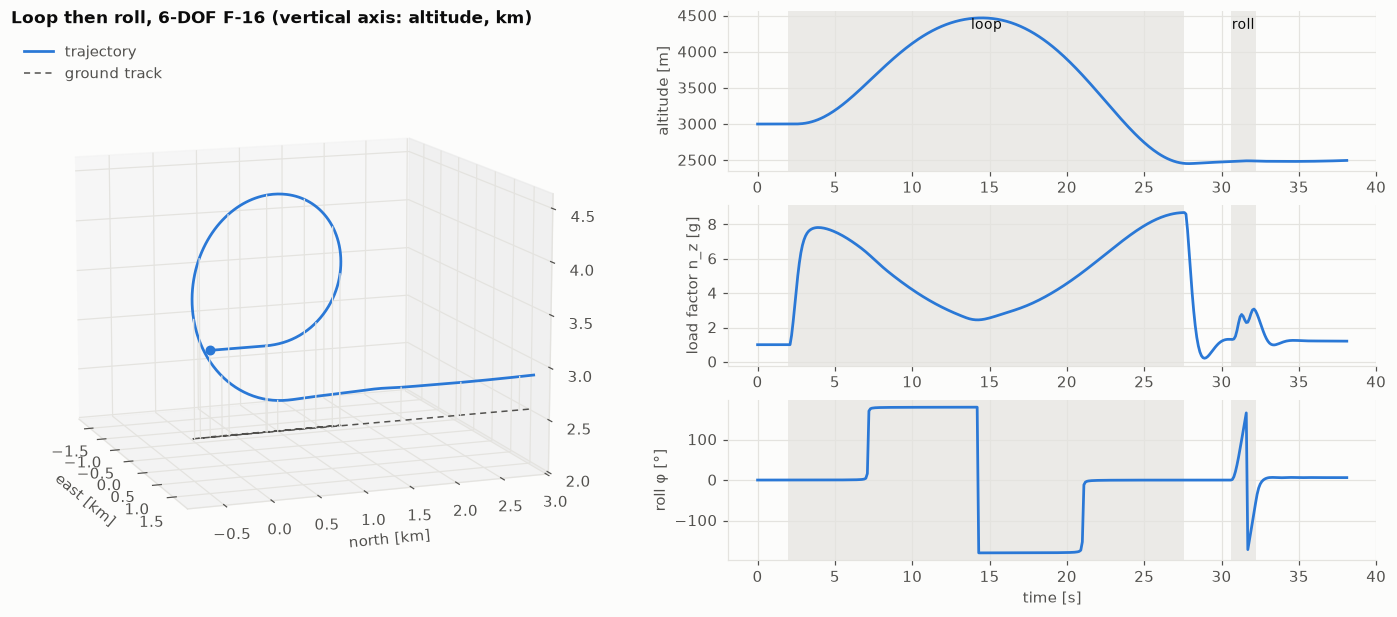

In [5]:
ins = flight.instruments
fig = plt.figure(figsize=(13, 5.5), layout="constrained")
left, right = fig.subfigures(1, 2, width_ratios=[1, 1.1])
ax3d = left.add_subplot(projection="3d")
east, north, alt = ins["east"] / 1000, ins["north"] / 1000, ins["altitude"] / 1000
ax3d.plot(east, north, alt, color=SERIES[0], label="trajectory")
ax3d.plot(
    east,
    north,
    np.full_like(alt, alt.min() - 0.3),
    color=INK_2,
    linewidth=1,
    linestyle=(0, (4, 3)),
    label="ground track",
)
for k in range(0, len(east), 25):
    ax3d.plot([east[k]] * 2, [north[k]] * 2, [alt.min() - 0.3, alt[k]], color=GRID, linewidth=0.8)
ax3d.scatter(east[0], north[0], alt[0], color=SERIES[0], s=30)
ax3d.set_xlabel("east [km]"), ax3d.set_ylabel("north [km]")
span = max(np.ptp(east), np.ptp(north)) / 2
ax3d.set_xlim(east.mean() - span, east.mean() + span)
ax3d.set_ylim(north.mean() - span, north.mean() + span)
ax3d.view_init(elev=12, azim=-20)
ax3d.set_title("Loop then roll, 6-DOF F-16 (vertical axis: altitude, km)", loc="left")
ax3d.legend(loc="upper left")

panels = [
    ("altitude", 1.0, "altitude [m]"),
    ("nz", 1.0, "load factor n_z [g]"),
    ("roll", 1 / DEG, "roll φ [°]"),
]
axes = []
for row, (key, scale, label) in enumerate(panels):
    ax = right.add_subplot(3, 1, row + 1, sharex=axes[0] if axes else None)
    ax.plot(flight.t, ins[key] * scale, color=SERIES[0])
    ax.set_ylabel(label)
    axes.append(ax)
events = dict((msg, t_ev) for t_ev, msg in flight.events)
for name, start, stop in (("loop", "loop", "level after loop"), ("roll", "roll", "end")):
    for ax in axes:
        ax.axvspan(events[start], events[stop], color=GRID, alpha=0.7, linewidth=0)
    axes[0].text(
        (events[start] + events[stop]) / 2,
        ins["altitude"].max(),
        name,
        ha="center",
        va="top",
        color=INK,
        fontsize=9,
    )
axes[-1].set_xlabel("time [s]")
plt.show()

Reading the plots: during the loop the load factor is highest at entry and exit (~8 g, fast)
and lowest at the top (~2.5 g, slow and inverted). The roll angle jumps to ±180° *during the
loop* although the aircraft never rolls: that is the Euler-angle artifact of notebook 1 each
time the nose passes the vertical. The real roll is the short sweep at the end.

## 4. Tacview export

[Tacview](https://www.tacview.net) (free version) replays flights on a 3D globe with the
aircraft's attitude, trail and telemetry. Its ACMI format is plain text: a header, then one
line per object per frame, `id,T=lon|lat|alt|roll|pitch|yaw,...`. The project's flat-Earth NED
coordinates are "placed" above the Atlantic (46° N, 6° W) so no terrain gets in the way.

In [6]:
acmi = export_recording(
    flight, TMP / "demo.acmi", pilot="Scripted demo", title="Scripted demo: loop + roll"
)
lines = acmi.read_text(encoding="utf-8").splitlines()
print(f"{acmi.name}: {len(lines)} lines\n")
print("\n".join(line[:110] for line in lines[:14]))

demo.acmi: 776 lines

FileType=text/acmi/tacview
FileVersion=2.2
0,ReferenceTime=2026-01-01T12:00:00Z
0,ReferenceLongitude=-6
0,ReferenceLatitude=46
0,Title=Scripted demo: loop + roll
0,Author=JetFighter_RL
0,DataSource=JetFighter_RL (simulation)
#0
101,T=0|0|3000|0|0.42|0,Name=F-16C,Type=Air+FixedWing,Color=Blue,Coalition=Allies,Pilot=Scripted demo,TAS=250,
#0.1
101,T=0|0.0002248|3000|0|0.42|0,TAS=250,CAS=219.679,Mach=0.761,AOA=0.42,AOS=0,AGL=3000,Throttle=0.24
#0.2
101,T=0|0.0004497|3000|0|0.42|0,TAS=250,CAS=219.679,Mach=0.761,AOA=0.42,AOS=0,AGL=3000,Throttle=0.24


The same writer supports several objects per file: in notebook 8 the RL agent (blue) and the
autopilot (orange) fly the same scenario side by side, with the waypoints drawn in green —
and in phase 9 the missile will be one more object.

## 5. Manual flight

`scripts/fly_manual.py` opens a pygame window with an artificial horizon and instruments, and
maps the keyboard (or a joystick) to the controls, with a spring-loaded "virtual stick":

* **6-DOF**: elevator = trim − 12° × pitch stick, ailerons = −15° × roll stick, rudder = −15° ×
  pedals — direct surface control, no assistance;
* **3-DOF**: angle-of-attack and roll-rate commands.

Each flight is saved automatically (`.npz`, `.acmi`, `.png`). If a recording of a human flight
exists locally, here it is (these files are not versioned):

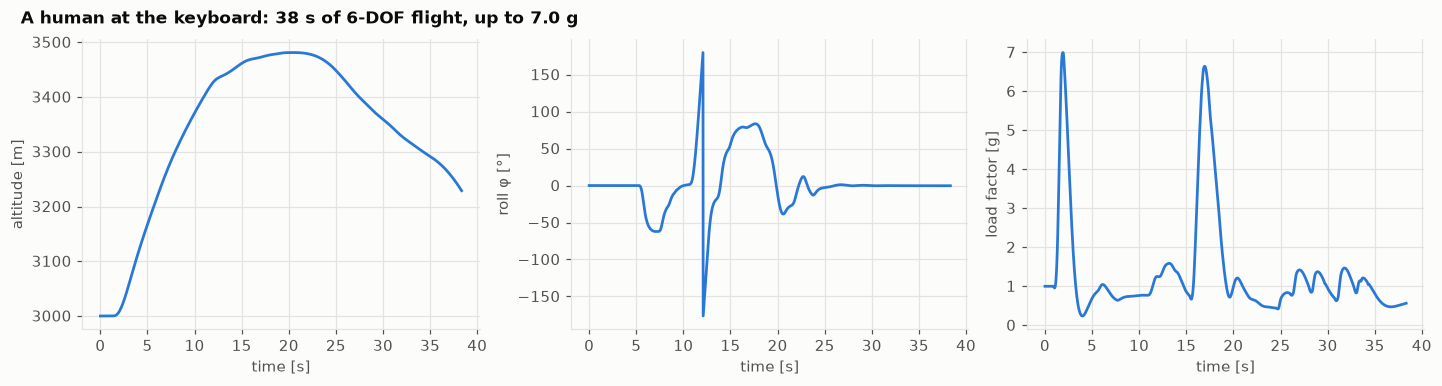

In [7]:
human = sorted((ROOT / "outputs" / "flights").glob("manuel_6dof_*.npz"))
if human:
    rec = FlightRecording.load(human[-1])
    hi = rec.instruments
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), layout="constrained")
    axes[0].plot(rec.t, hi["altitude"], color=SERIES[0])
    axes[0].set_ylabel("altitude [m]")
    axes[1].plot(rec.t, np.degrees(hi["roll"]), color=SERIES[0])
    axes[1].set_ylabel("roll φ [°]")
    axes[2].plot(rec.t, hi["nz"], color=SERIES[0])
    axes[2].set_ylabel("load factor [g]")
    for ax in axes:
        ax.set_xlabel("time [s]")
    fig.suptitle(
        f"A human at the keyboard: {rec.duration:.0f} s of 6-DOF flight, "
        f"up to {hi['nz'].max():.1f} g",
        color=INK,
        fontweight="bold",
        x=0.01,
        ha="left",
    )
    plt.show()
else:
    print(
        "No manual flight recorded yet: run `python scripts/fly_manual.py` (needs the [viz] extra)."
    )

Flying the raw 6-DOF model by keyboard is possible but demanding: every turn needs coordinated
aileron, back-pressure and rudder, and nothing holds the altitude for you. That experience is
the motivation for the next phase: a fly-by-wire system and an autopilot.

## Takeaways

* Every flight — scripted, human, autopilot or RL agent — goes through the **same recorder**,
  so the same plots and Tacview files work for all of them.
* **Deterministic, bit-exact replay** makes any training episode reproducible and debuggable.
* Visual inspection is a first-class validation tool: in phase 8 it caught five cases of
  *reward hacking* that the reward curves did not reveal.

**Next:** notebook 6 — the classical controllers that the RL agent must match.